In [1]:
# conda activate anndata

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [8]:
import os

os.getcwd()

'/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/bulk/GTEx/frontal_cortex'

# Prep eigenges

In [95]:
# top_mods_df1_MO = pd.read_csv("data/EA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_MO_1354sets_EA_top_Qval_mods.csv")

# cts = [
#     "LAKE_2018_EX1_DE_EX_CLUSTERS", # excitatory?
#     "OLDHAM_CAUDATE_NUCLEUS_MODULE_ORANGE" # glial?
#     "LAU_2020_INHIT" # all neuronal?
# ]

In [96]:
top_mods_df1_Cur = pd.read_csv("data/EA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_EA_top_Qval_mods.csv")

cts = ["CGE Class"]

top_mods_df1_Cur = top_mods_df1_Cur[top_mods_df1_Cur['Cell_type'].isin(cts)]
top_mods_df1_Cur = top_mods_df1_Cur.rename(columns={"Module": "Mod"})

In [97]:
top_mods_df1_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")

cts = [
    "Micro/PVM", "All GABAergic", "Oligo", "Astro",
    "OPC", # immature OPCs
    "All Neuronal", "Endo",
    "L6 IT", "L2/3 IT"
]
top_mods_df1_FGSEA = top_mods_df1_FGSEA[top_mods_df1_FGSEA['Cell_type'].isin(cts)]
top_mods_df1_FGSEA.loc[top_mods_df1_FGSEA['Cell_type'] == "OPC", 'Cell_type'] = "Immature OPC"


In [98]:
top_mods_df2_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.93_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")
cts = ["OPC"]
top_mods_df2_FGSEA = top_mods_df2_FGSEA[top_mods_df2_FGSEA['Cell_type'].isin(cts)]

In [99]:
top_mods_df = pd.concat([top_mods_df1_Cur, top_mods_df1_FGSEA, top_mods_df2_FGSEA])

In [100]:
results = []
for idx, row in top_mods_df.iterrows():
    modEig = pd.read_csv(row['ME_path'], index_col=0)[row['Mod']]
    modEig.name = row['Cell_type']
    results.append(modEig)
    
eigengene_df = pd.concat(results, axis=1)

In [101]:
eigengene_df.head()

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Immature OPC,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Sample,,,,,,,,,,,
GTEX.12126.0011.R10b.SM.5BC6T,0.146810,0.095824,-0.042099,-0.070946,-0.035843,-0.048949,-0.040700,-0.020068,-0.049773,0.045241,0.109267
GTEX.1F7RK.0011.R10b.SM.ARU7Y,0.068079,0.085535,0.021223,-0.019596,-0.093812,-0.032658,0.016217,0.066036,0.118367,0.049196,0.008826
GTEX.T5JC.0011.R10A.SM.32PM2,0.012689,0.001989,0.021835,-0.033105,-0.058511,-0.055091,-0.011044,0.035662,-0.018728,0.065645,0.002820
GTEX.WHSE.0011.R10A.SM.EYYVG,0.073536,0.084961,0.074458,-0.008586,0.003785,0.003180,0.018067,-0.011331,0.004621,-0.023154,0.083886
GTEX.11ZUS.0011.R10b.SM.5BC79,0.027794,0.012384,0.147081,-0.040491,-0.050823,-0.029318,0.478469,-0.061926,-0.062080,-0.048608,0.013112


In [102]:
# eigengene_df.to_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance.csv")

# Gene expression vs. eigengene

In [103]:
bulk_expr = pd.read_csv("GTEx_frontal_cortex_counts_TMMF_SampleNetworks/All_10-58-02/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed.csv")
bulk_expr.columns.values[0] = "Gene"

In [104]:
# Make sure samples are in the same order

bulk_expr = bulk_expr.set_index("Gene")
common = bulk_expr.columns.intersection(eigengene_df.index)
bulk_expr = bulk_expr[common]
eigengene_df = eigengene_df.loc[common]

In [105]:
eigengene_df.shape

(200, 11)

In [ ]:
# Correlate each cell type with gene expression

expr_corr_results = {}
for ct in eigengene_df.columns:
    expr_corr_results[ct] = bulk_expr.T.corrwith(eigengene_df[ct])
    
expr_corr_df = pd.DataFrame(expr_corr_results)

In [ ]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(10)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Immature OPC,Endo,All Neuronal,Peri,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,,,
DLG3,0.709528,0.841923,-0.019349,0.013993,-0.227879,-0.026093,-0.128760,0.986240,-0.278624,0.754759,0.810542,0.195802
ADD2,0.658479,0.814661,-0.000556,0.040960,-0.211003,-0.015809,-0.113088,0.985687,-0.270191,0.793453,0.781297,0.210593
SMAP2,0.699750,0.835714,0.076540,0.046832,-0.178368,0.013700,-0.076955,0.983650,-0.242165,0.751156,0.798369,0.215937
RAB6B,0.690386,0.833131,0.030397,0.003478,-0.176850,-0.026554,-0.100993,0.983148,-0.251558,0.743738,0.802630,0.218822
SPATS2,0.655802,0.800459,0.057733,0.029383,-0.183947,-0.014808,-0.076134,0.982968,-0.247851,0.750896,0.803426,0.212211
GNB5,0.697305,0.845314,0.049229,0.017356,-0.149856,0.016107,-0.076487,0.982939,-0.210553,0.775570,0.784948,0.239366
MAP2K4,0.660316,0.825267,0.028636,0.058589,-0.233930,-0.032188,-0.098147,0.982759,-0.299772,0.791501,0.771473,0.217994
NDRG3,0.663725,0.836523,0.056203,0.056082,-0.184723,-0.006406,-0.072567,0.982756,-0.251272,0.779524,0.759593,0.215162
STXBP1,0.634944,0.804396,-0.006763,0.022965,-0.245999,-0.059175,-0.138165,0.982309,-0.315056,0.799365,0.757398,0.142377


# Cluster eigengenes by correlation

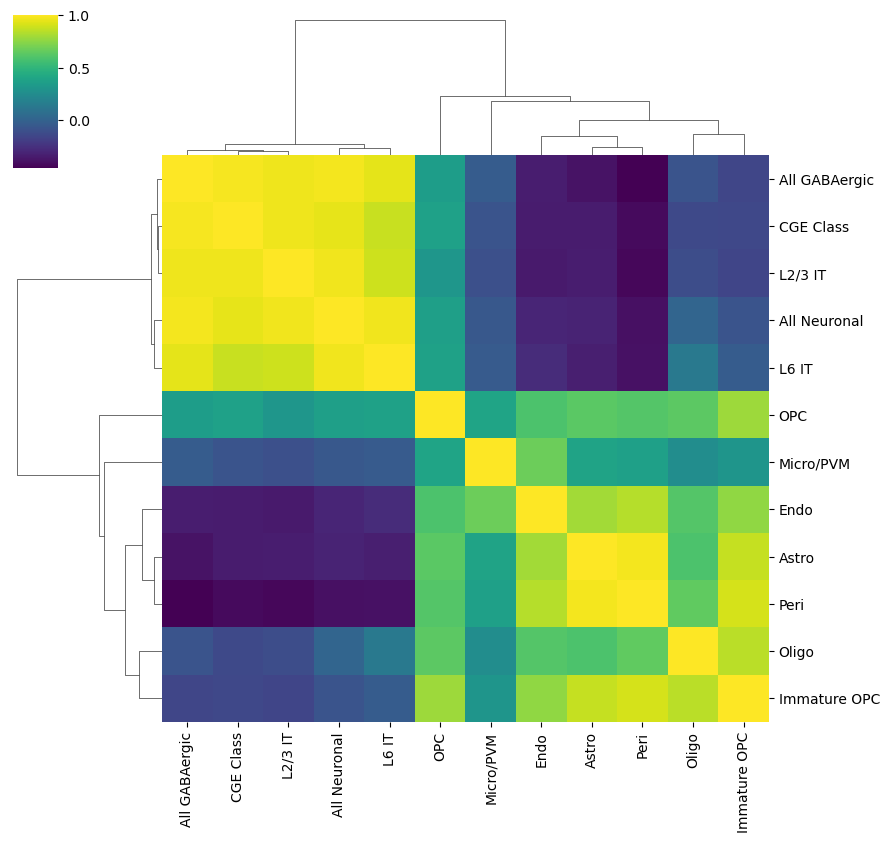

In [94]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(9, 8.5))

# Manually inspect top genes

In [ ]:
cts_to_keep = []

# Filter eigengenes

In [ ]:
ctype_abundance_filt = ctype_abundance_df.loc[:, keep]

In [ ]:
ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L6 IT': 'Deep layer glutamatergic'})

ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L2/3 IT': 'Upper layer glutamatergic'})

In [ ]:
abund_corr_mat = ctype_abundance_filt.corr()
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

In [ ]:
ctype_abundance_filt.to_csv("data/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_filtered.csv")